# Find alpha DSE1-4

May 4, 2025 - An attempt to reproduce the find alpha parameter using the DSE genes. The differences in the replicate fits and the shorter delta values make this procedure difficult to reliably reproduce consistently across both replicates. Replicate 1 produces very long alphas > 28, replicate 2 produces very short ones < 8. Whereas we would expect values between 12-20 proportionally to the length of the cell cycle as per Xin Guo's work.


In [2]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [3]:
from pipeline.CombinedDeconvolveGeneExpressionRunner import CombinedDeconvolveGeneExpressionRunner
output_directory = 'output/draft3_run/'
runner = CombinedDeconvolveGeneExpressionRunner(output_directory, False)

In [4]:
runner.config1.modify_alpha(30)

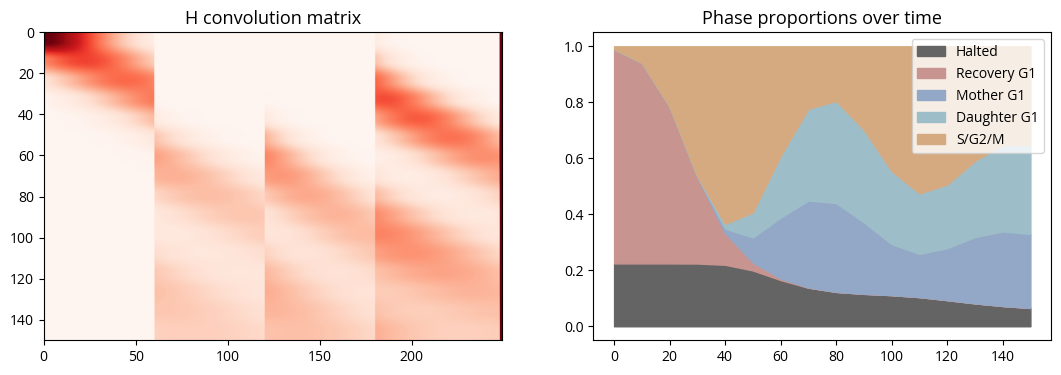

In [5]:
runner.config1.plot_H()

In [6]:
runner.deconvolve_gene_find_gamma('CLB2', replicate=1)

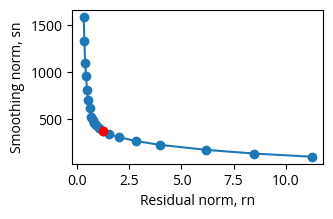

In [7]:
runner.expression_find_gamma.gamma_optimizer.plot_elbow()

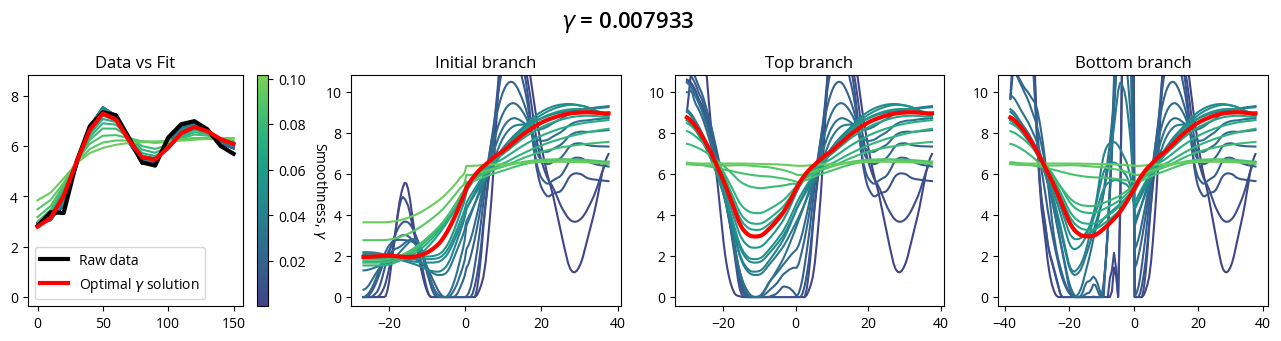

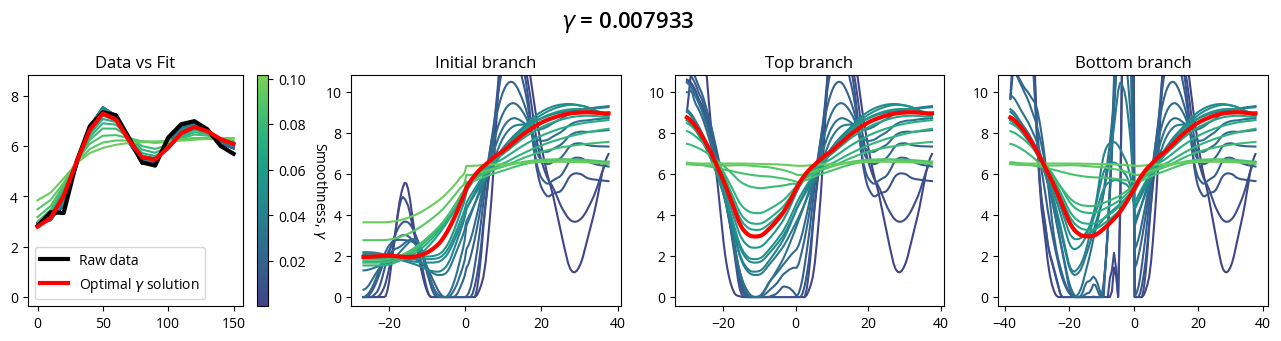

In [8]:
runner.expression_find_gamma.plot_gamma_sweep()

In [9]:
# Last check does the number of indices help?
from src.deconvolution_solver import DeconvolutionSolver

config = runner.expression_find_gamma.deconvolution_solver.config

test_solver = DeconvolutionSolver(config,
    runner.expression_find_gamma.deconvolution_solver.g,
    config.H, 0.008, kappa=0.0)
test_solver.verbose=True
test_solver.deconvolve()


Fit norm: 1.2660709430714665
Smoothing norm: 367.3073217151515
Initial smoothing result:  84.84496086600723
Top smoothing result:  98.81870746791431
Bottom smoothing result:  98.79869251522274


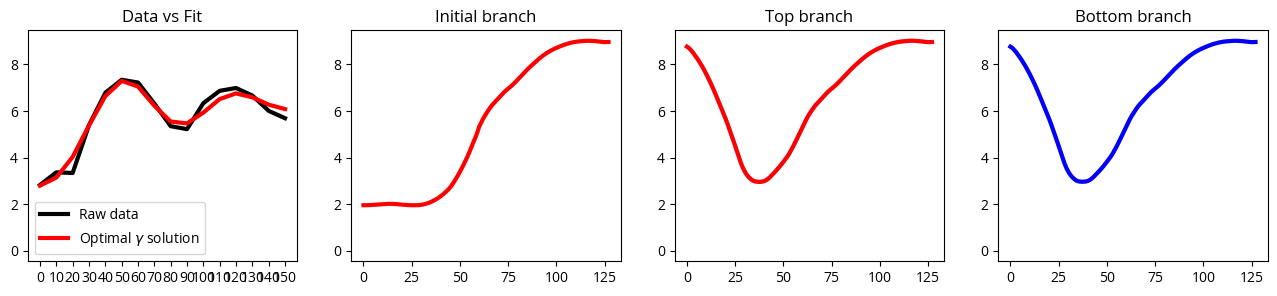

In [10]:
test_solver.plot_fit()